In [10]:
import matplotlib.pyplot as plt
import networkx as nx
import requests
import csv
import os
import time
from dotenv import load_dotenv

In [11]:
load_dotenv()

API_KEY = os.getenv("STEAM_API_KEY")

In [ ]:
# LEMBRE-SE: Não deixe sua chave real exposta!
BASE = "https://api.steampowered.com"

def get_user_details(steam_id):
    """Busca informações de perfil e biblioteca de jogos do usuário."""
    details = {
        "pais": "N/A",
        "total_jogos": 0,
        # Guardaremos os IDs dos jogos separados por ; para não quebrar a formatação do CSV
        "jogos_ids": "" 
    }
    
    # 1. Resumo do Jogador (Nome, País)
    url_summary = f"{BASE}/ISteamUser/GetPlayerSummaries/v2/"
    r_sum = requests.get(url_summary, params={"key": API_KEY, "steamids": steam_id})
    if r_sum.status_code == 200:
        players = r_sum.json().get("response", {}).get("players", [])
        if players:
            details["pais"] = players[0].get("loccountrycode", "N/A")
            
    # 2. Jogos Possuídos
    url_games = f"{BASE}/IPlayerService/GetOwnedGames/v0001/"
    r_games = requests.get(url_games, params={"key": API_KEY, "steamid": steam_id})
    if r_games.status_code == 200:
        resp = r_games.json().get("response", {})
        details["total_jogos"] = resp.get("game_count", 0)
        games = resp.get("games", [])
        
        # Extrai os AppIDs dos jogos e junta numa string (Ex: "730;4000;252490")
        details["jogos_ids"] = ";".join([str(g.get("appid")) for g in games])
        
    return details

def get_friends(steam_id):
    url = f"{BASE}/ISteamUser/GetFriendList/v1/"
    params = {
        "key": API_KEY,
        "steamid": steam_id,
        "relationship": "friend"
    }
    r = requests.get(url, params=params)
    if r.status_code != 200:
        return []
    data = r.json()
    if "friendslist" not in data:
        return []
    return [f["steamid"] for f in data["friendslist"]["friends"]]

def construir_grafo_social(steam_ids_sementes, profundidade_maxima=1):
    G = nx.Graph()
    fila = [(steam_id, 0) for steam_id in steam_ids_sementes]
    visitados = set()
    
    while fila:
        atual_id, nivel = fila.pop(0)
        
        if atual_id in visitados:
            continue
        
        print(f"Coletando dados de: {atual_id} (Nível {nivel}) - Nós na fila {len(fila)}...")
            
        visitados.add(atual_id)
        
        try:
            # 1. Busca detalhes do usuário e adiciona como atributos no nó
            detalhes = get_user_details(atual_id)
            G.add_node(atual_id, **detalhes)
            
            # 2. Busca lista de amigos
            amigos = get_friends(atual_id) 
            for amigo_id in amigos:
                # O NetworkX cria automaticamente o nó 'amigo_id' se ele não existir
                if nivel <= profundidade_maxima:
                    G.add_edge(atual_id, amigo_id)
                
                    fila.append((amigo_id, nivel + 1))
                    
        except Exception as e:
            print(f"Erro ao buscar dados do ID {atual_id}: {e}")
            
    return G

def salvar_grafo_csv(G, arquivo_nos='steam_nos.csv', arquivo_arestas='steam_arestas.csv'):
    """Salva os nós (com atributos dinâmicos) e arestas em CSV."""
    
    # Salvar Nós
    with open(arquivo_nos, mode='w', newline='', encoding='utf-8') as f:
        # Pega todas as chaves de atributos que existem no grafo para fazer o cabeçalho
        todas_chaves = set()
        for _, dados in G.nodes(data=True):
            todas_chaves.update(dados.keys())
            
        cabecalho = ['steam_id'] + list(todas_chaves)
        writer = csv.DictWriter(f, fieldnames=cabecalho)
        writer.writeheader()
        
        for steam_id, dados in G.nodes(data=True):
            linha = {'steam_id': steam_id}
            linha.update(dados)
            writer.writerow(linha)
            
    # Salvar Arestas
    with open(arquivo_arestas, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['source', 'target'])
        for u, v in G.edges():
            writer.writerow([u, v])
            
    print(f"Grafo salvo com sucesso em '{arquivo_nos}' e '{arquivo_arestas}'.")

def carregar_grafo_csv(arquivo_nos='steam_nos.csv', arquivo_arestas='steam_arestas.csv'):
    """Carrega o grafo restaurando os atributos guardados no CSV."""
    G = nx.Graph()
    
    try:
        # Carregar Nós com Atributos
        with open(arquivo_nos, mode='r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                steam_id = row.pop('steam_id') # Remove o ID do dicionário para usá-lo como chave principal
                # O resto do dicionário 'row' vira atributos do nó
                G.add_node(steam_id, **row)
                
        # Carregar Arestas
        with open(arquivo_arestas, mode='r', encoding='utf-8') as f:
            reader = csv.DictReader(f)
            for row in reader:
                G.add_edge(row['source'], row['target'])
                
        print("Grafo carregado com sucesso dos arquivos CSV.")
    except FileNotFoundError as e:
        print(f"Erro ao carregar o grafo: O arquivo não foi encontrado. Detalhes: {e}")
        
    return G

if __name__ == "__main__":
    seeds = [
      "76561198320338168", 
    #   "76561199159522860",
    #   "76561198145467769",
    ]
    
    print("Iniciando a coleta de dados da API...")
    grafo_steam = construir_grafo_social(seeds, profundidade_maxima=1)
    print(f"\nGrafo construído! Nós: {grafo_steam.number_of_nodes()} | Arestas: {grafo_steam.number_of_edges()}")
    
    salvar_grafo_csv(grafo_steam, 'steam_nos.csv', 'steam_arestas.csv')
    
    print("\nTestando o recarregamento do grafo offline...")
    grafo_offline = carregar_grafo_csv('steam_nos.csv', 'steam_arestas.csv')
    
    # Exemplo: Acessando os dados de um nó específico após carregar do CSV
    seed_teste = "76561198320338168"
    if seed_teste in grafo_offline:
        dados = grafo_offline.nodes[seed_teste]
        print(f"\nDados carregados para o ID {seed_teste}:")
        print(f"- Nome: {dados.get('nome')}")
        print(f"- País: {dados.get('pais')}")
        print(f"- Total de Jogos: {dados.get('total_jogos')}")

Iniciando a coleta de dados da API...
Coletando dados de: 76561198320338168 (Nível 0) - Nós na fila 0...
Coletando dados de: 76561198103820259 (Nível 1) - Nós na fila 17...
Coletando dados de: 76561198166489597 (Nível 1) - Nós na fila 96...
Coletando dados de: 76561198261886351 (Nível 1) - Nós na fila 95...
Coletando dados de: 76561198285534477 (Nível 1) - Nós na fila 110...
Coletando dados de: 76561198308806757 (Nível 1) - Nós na fila 239...
Coletando dados de: 76561198365721356 (Nível 1) - Nós na fila 270...
Coletando dados de: 76561198397177352 (Nível 1) - Nós na fila 286...
Coletando dados de: 76561198400024070 (Nível 1) - Nós na fila 359...
Coletando dados de: 76561198408714684 (Nível 1) - Nós na fila 563...
Coletando dados de: 76561198577817824 (Nível 1) - Nós na fila 719...
Coletando dados de: 76561198797624743 (Nível 1) - Nós na fila 784...
Coletando dados de: 76561198802351715 (Nível 1) - Nós na fila 810...
Coletando dados de: 76561198806973520 (Nível 1) - Nós na fila 875...
C

In [7]:
# 1. Análise Macro: Qual o tamanho da nossa rede?
print("=== ESTATÍSTICAS GERAIS ===")
print(f"Total de Jogadores na rede: {grafo_steam.number_of_nodes()}")
print(f"Total de Amizades mapeadas: {grafo_steam.number_of_edges()}")

# 2. Centralidade de Grau (Degree Centrality): Quem são os "Hubs"?
# Isso revela quem são os jogadores mais conectados e influentes dentro dessa bolha.
centralidade = nx.degree_centrality(grafo_steam)
top_influencers = sorted(centralidade.items(), key=lambda x: x[1], reverse=True)[:5]

print("\n=== TOP 5 JOGADORES MAIS CONECTADOS ===")
for node, score in top_influencers:
    # Multiplicamos por 100 para ver como porcentagem de conexão na rede
    print(f"Steam ID {node}: Conectado a {score * 100:.1f}% da rede")

# 3. Detecção de Comunidades (Clustering): Quais são os "esquadrões"?
# Divide o grafo em grupos onde os jogadores jogam/são muito amigos entre si.
from networkx.algorithms.community import greedy_modularity_communities

comunidades = greedy_modularity_communities(grafo_steam)
print(f"\n=== COMUNIDADES DETECTADAS ===")
print(f"Foram identificados {len(comunidades)} grupos isolados ou sub-bolhas.")

for i, comunidade in enumerate(comunidades[:3]): # Mostrando os 3 maiores grupos
    print(f"Grupo {i+1}: {len(comunidade)} membros")

=== ESTATÍSTICAS GERAIS ===
Total de Jogadores na rede: 27722
Total de Amizades mapeadas: 39695

=== TOP 5 JOGADORES MAIS CONECTADOS ===
Steam ID 76561198844148470: Conectado a 2.8% da rede
Steam ID 76561198046775968: Conectado a 2.4% da rede
Steam ID 76561198013999805: Conectado a 2.3% da rede
Steam ID 76561199045873746: Conectado a 2.2% da rede
Steam ID 76561198083407455: Conectado a 2.2% da rede

=== COMUNIDADES DETECTADAS ===
Foram identificados 82 grupos isolados ou sub-bolhas.
Grupo 1: 6489 membros
Grupo 2: 1874 membros
Grupo 3: 1034 membros


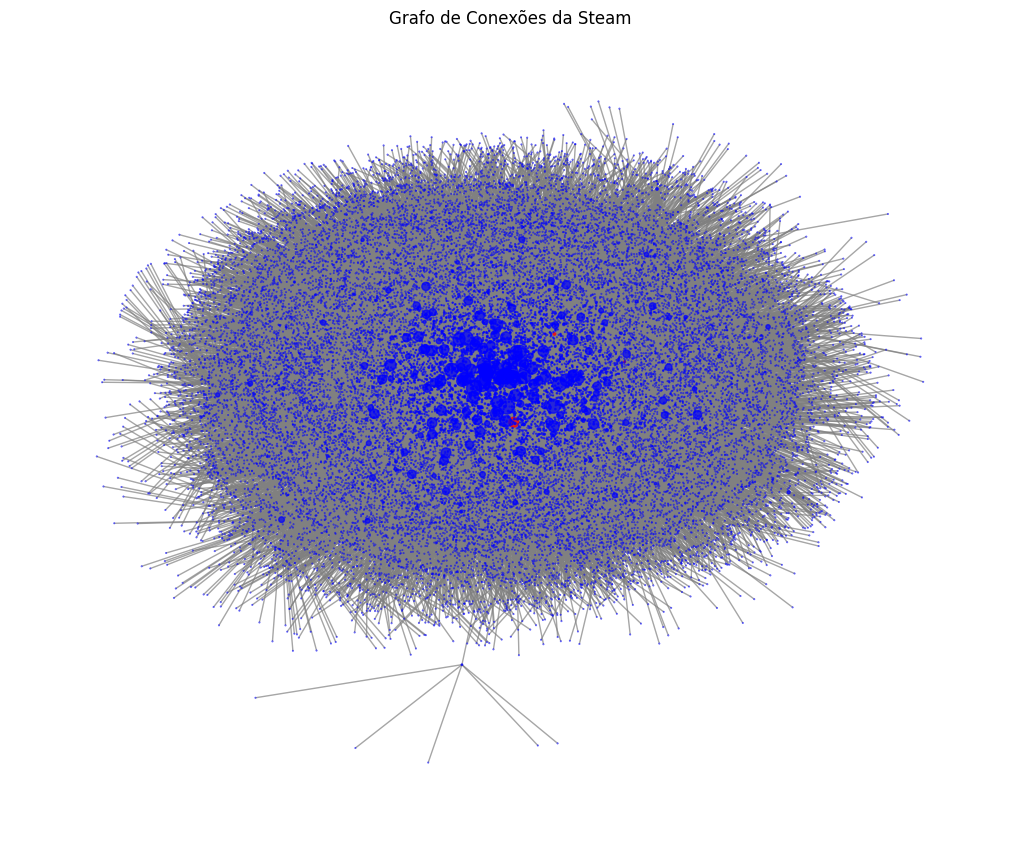

In [8]:
# Mapeia as cores: Vermelho para o jogador raiz, Azul para os demais
cores = ["red" if node in seeds else "blue" for node in grafo_steam.nodes()]

# Define o tamanho dos nós baseado na influência (centralidade) deles
tamanhos = [centralidade[node] * 5000 for node in grafo_steam.nodes()]

plt.figure(figsize=(10, 8))
nx.draw(
    grafo_steam, 
    node_color=cores, 
    node_size=tamanhos, 
    with_labels=False, 
    alpha=0.7, 
    edge_color="gray"
)
plt.title("Grafo de Conexões da Steam")
plt.show()

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def analisar_estatisticas_grafo(G):
    print("\n" + "="*40)
    print("ESTATÍSTICAS GERAIS DO GRAFO")
    print("="*40)
    
    # 1. Estatísticas Básicas
    num_nos = G.number_of_nodes()
    num_arestas = G.number_of_edges()
    print(f"Total de Nós (Usuários): {num_nos}")
    print(f"Total de Arestas (Conexões): {num_arestas}")
    
    if num_nos == 0:
        print("Grafo vazio!")
        return

    # 2. Análise de Graus (Conexões por nó)
    graus = [grau for no, grau in G.degree()]
    grau_medio = sum(graus) / num_nos
    grau_maximo = max(graus)
    print(f"Grau Médio (Amigos por usuário no grafo): {grau_medio:.2f}")
    print(f"Grau Máximo (O usuário mais conectado tem): {grau_maximo} conexões")
    
    # 3. Densidade
    densidade = nx.density(G)
    print(f"Densidade da Rede: {densidade:.6f}")
    
    # 4. Componentes Conectados
    componentes = nx.number_connected_components(G)
    print(f"Componentes Conectados (Grupos isolados): {componentes}")
    
    # 5. Coeficiente de Agrupamento (Clustering)
    # Nota: Pode demorar alguns segundos em grafos muito grandes (> 10.000 nós)
    clustering_medio = nx.average_clustering(G)
    print(f"Coeficiente de Agrupamento Médio: {clustering_medio:.4f}")

    # 6. Identificar os "Top Hubs" (Nós com mais conexões)
    print("\n--- TOP 5 USUÁRIOS MAIS CONECTADOS ---")
    hubs = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:5]
    for steam_id, grau in hubs:
        # Tenta pegar o nome se o nó tiver esse atributo salvo no CSV
        print(f"ID: {steam_id} | Conexões: {grau}")

    # 7. Plotar o Histograma de Graus
    plotar_histograma_graus(graus)

def plotar_histograma_graus(graus):
    plt.figure(figsize=(10, 6))
    
    # Usamos bins automáticos ou definimos limites baseados no grau máximo
    plt.hist(graus, bins=50, color='#1b2838', edgecolor='#66c0f4', alpha=0.8)
    
    plt.title('Distribuição de Graus na Rede da Steam', fontsize=16, fontweight='bold', color='#333333')
    plt.xlabel('Grau (Número de Conexões)', fontsize=12)
    plt.ylabel('Frequência (Número de Usuários)', fontsize=12)
    
    # Opcional: Para redes sociais, uma escala logarítmica geralmente ajuda a visualizar melhor,
    # já que muitos têm poucos amigos e poucos têm muitos amigos.
    # plt.yscale('log') # Descomente esta linha se o gráfico normal ficar difícil de ler
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [18]:
from collections import Counter

def plotar_analises_extras(G):
    # Prepara os dados extraindo dos nós
    graus = dict(G.degree())
    total_jogos = []
    graus_lista = []
    paises = []
    
    for no, dados in G.nodes(data=True):
        # Tenta pegar os atributos (com fallback para valores padrão se estiverem faltando)
        jogos_raw = dados.get('total_jogos', 0)
        
        # 2. Tenta converter para int de forma segura
        try:
            jogos = int(jogos_raw)
        except (ValueError, TypeError):
            # Se for uma string vazia ('') ou um tipo inválido, assumimos 0
            jogos = 0
            
        pais = dados.get('pais', 'N/A')
        
        total_jogos.append(jogos)
        graus_lista.append(graus[no])
        
        if pais and pais != 'N/A' and pais != '':
            paises.append(pais)

    # Cria uma figura com 3 subgráficos (1 linha, 3 colunas)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    # --- GRÁFICO 1: Dispersão (Grau vs Jogos) ---
    axs[0].scatter(graus_lista, total_jogos, alpha=0.5, color='#c44e52')
    axs[0].set_title('Conexões vs. Total de Jogos')
    axs[0].set_xlabel('Número de Conexões (Grau)')
    axs[0].set_ylabel('Total de Jogos na Conta')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    # --- GRÁFICO 2: Top 10 Países ---
    contagem_paises = Counter(paises).most_common(10)
    if contagem_paises:
        nomes_paises = [p[0] for p in contagem_paises]
        quantidades = [p[1] for p in contagem_paises]
        
        axs[1].bar(nomes_paises, quantidades, color='#4c72b0')
        axs[1].set_title('Top 10 Países na Rede')
        axs[1].set_xlabel('Código do País')
        axs[1].set_ylabel('Quantidade de Usuários')
    else:
        axs[1].text(0.5, 0.5, 'Sem dados de país suficientes', ha='center')
        axs[1].set_title('Top 10 Países na Rede')

    # --- GRÁFICO 3: Desenho do Grafo (Topologia) ---
    # Atenção: Se o grafo tiver milhares de nós, isso pode demorar e virar um "novelão de lã"
    axs[2].set_title('Visualização da Rede')
    axs[2].axis('off') # Tira os eixos
    
    # Define o tamanho do nó baseado no número de conexões (multiplicado por 10 para dar escala)
    tamanhos_nos = [graus[no] * 10 for no in G.nodes()]
    
    # Layout de mola (aproxima quem é amigo e afasta quem não é)
    pos = nx.spring_layout(G, seed=42) 
    nx.draw_networkx_nodes(G, pos, ax=axs[2], node_size=tamanhos_nos, node_color='#55a868', alpha=0.7)
    nx.draw_networkx_edges(G, pos, ax=axs[2], alpha=0.2, edge_color='#999999')

    plt.tight_layout()
    plt.show()

Grafo carregado com sucesso dos arquivos CSV.

ESTATÍSTICAS GERAIS DO GRAFO
Total de Nós (Usuários): 27723
Total de Arestas (Conexões): 39697
Grau Médio (Amigos por usuário no grafo): 2.86
Grau Máximo (O usuário mais conectado tem): 765 conexões
Densidade da Rede: 0.000103
Componentes Conectados (Grupos isolados): 2
Coeficiente de Agrupamento Médio: 0.0774

--- TOP 5 USUÁRIOS MAIS CONECTADOS ---
ID: 76561198844148470 | Conexões: 765
ID: 76561198046775968 | Conexões: 660
ID: 76561198013999805 | Conexões: 628
ID: 76561199045873746 | Conexões: 616
ID: 76561198083407455 | Conexões: 603


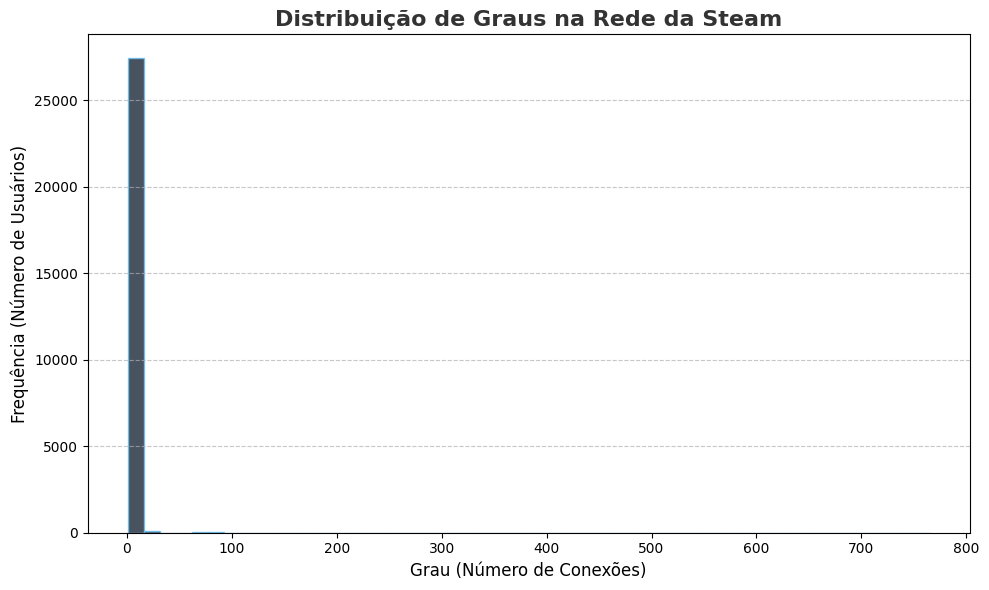

In [20]:
grafo_offline = carregar_grafo_csv('steam_nos.csv', 'steam_arestas.csv')    
analisar_estatisticas_grafo(grafo_offline)


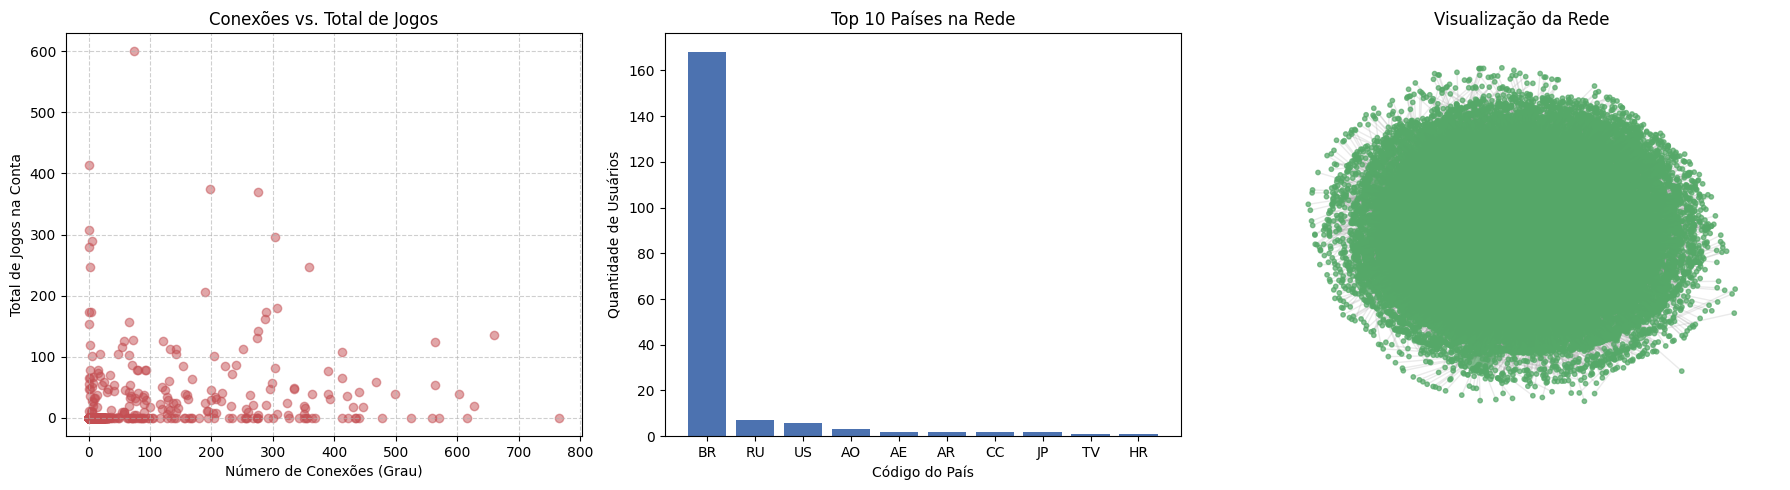

In [21]:
plotar_analises_extras(grafo_offline)